# Домашнее задание. Работа с пропусками и переменными

## 🎯 Цели задания

1. Научиться анализировать пропуски в данных.
2. Понять различные методы восстановления пропущенных значений.
3. Освоить методы масштабирования признаков.
4. Научиться кодировать категориальные переменные.
5. Понять важность валидации предобработки данных.
6. Работать с реальным датасетом Loan Prediction.

## 🧩 Задание

### Работайте с датасетом train.csv из архива Loan Prediction.

### Анализ пропусков

1. Для каждого столбца с пропусками рассчитайте % пропусков и определите тип переменной (числовая/категориальная).
2. На основе % пропусков и доменной логики составьте «матрицу решений»: какой метод применить к каждому столбцу.

,column,count,ptc_lost,dtype
0,Loan_ID,614,0.000000,str
1,Gender,601,2.117264,str
2,Married,611,0.488599,str
3,Dependents,599,2.442997,str
4,Education,614,0.000000,str
5,Self_Employed,582,5.211726,str
6,ApplicantIncome,614,0.000000,int64
7,CoapplicantIncome,614,0.000000,float64
8,LoanAmount,592,3.583062,float64
9,Loan_Amount_Term,600,2.280130,float64


<Axes: >

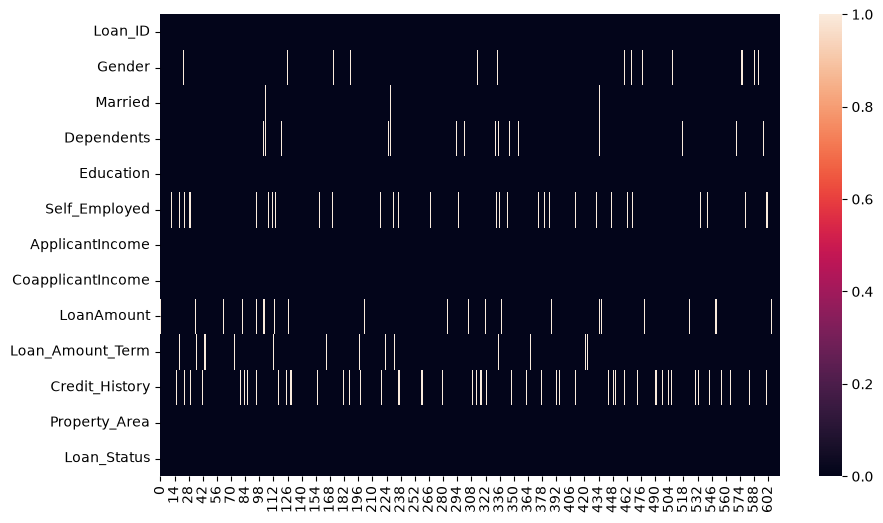

In [165]:
# Импортируйте необходимые библиотеки
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузите датасет train.csv
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
ln = len(df)

# Проанализируйте пропуски в данных
temp = df.count().reset_index()
temp.columns = ['column', 'count']
temp['ptc_lost'] = (1 - temp['count'] / ln) * 100
temp['dtype'] = df.dtypes.values
temp = temp[['column', 'count', 'ptc_lost', 'dtype']]
display(temp)

# Визуализируйте пропуски (например, с помощью seaborn.heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna().T, cmap='rocket', cbar=True)


### Матрица решений

На основе процента пропусков и доменной логики выбираем метод восстановления для каждого столбца:

| Колонка | % пропусков | Тип | Выбранный метод | Почему |
|---------|------------|-----|----------------|--------|
| LoanAmount | 3.58 | числовая | медиана + индикатор | распределение скошено, есть выбросы — медиана надёжнее среднего |
| Credit_History | 8.14 | бинарная | мода / IterativeImputer | бинарный 0/1, пропуск означает «нет истории» |
| Self_Employed | 5.21 | категориальная | мода | мало пропусков, категория заполняется самым частым |
| Dependents | 2.44 | категориальная | мода | мало пропусков |
| Gender | 2.12 | категориальная | мода | мало пропусков |
| Loan_Amount_Term | 2.28 | числовая | медиана | почти все значения = 360 (константа), медиана не исказит |
| Married | 0.49 | категориальная | мода | менее 1% пропусков — заполнение почти не влияет |

### Восстановление пропусков

1. Примените метод на выбор к одному числовому признаку с пропусками (например, LoanAmount):
   - медиана + индикатор пропуска
   - модельное восстановление
2. Визуализируйте распределения до обработки и после каждого метода (гистограммы + ящики с усами).

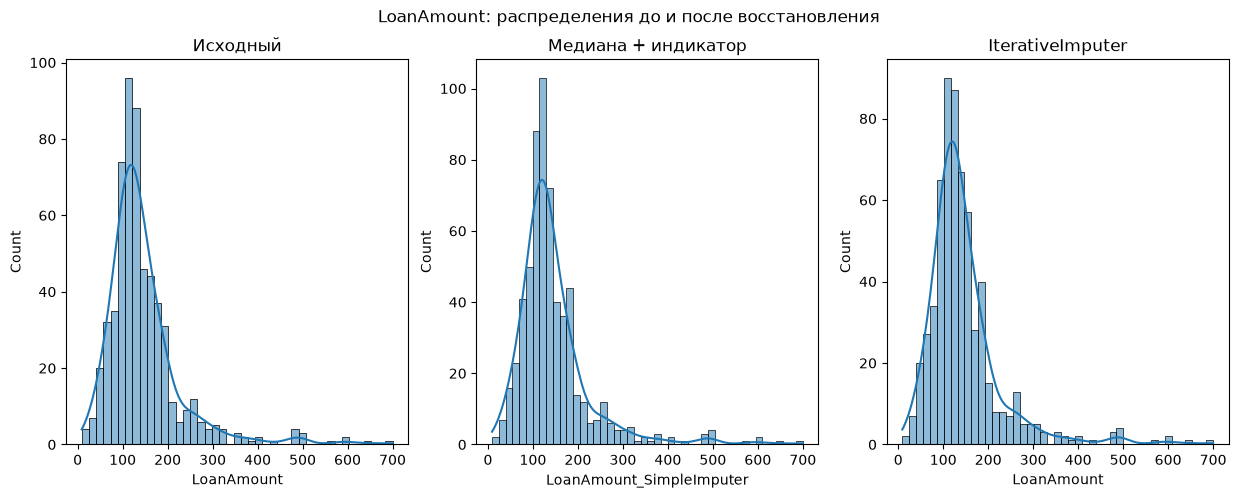

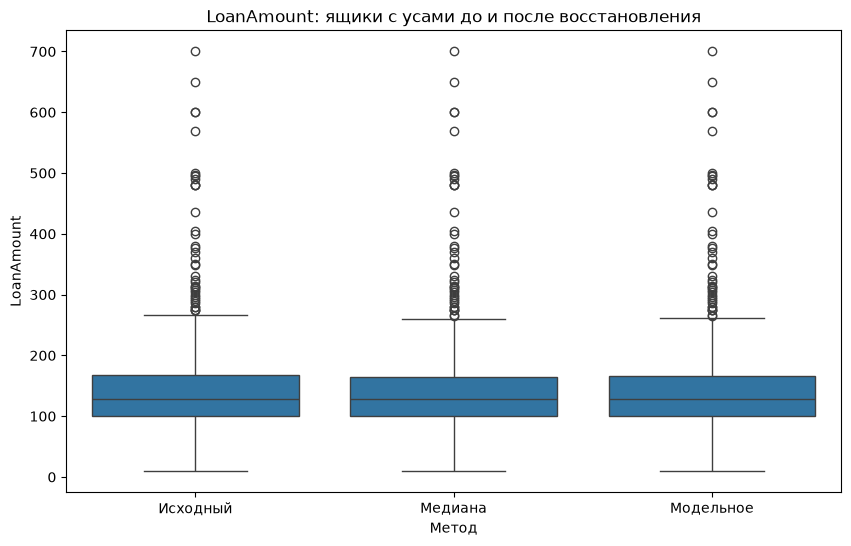

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_SimpleImputer,SimpleImputer_ind
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,138.159239,360.0,1.0,Urban,Y,128.0,1.0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N,128.0,0.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y,66.0,0.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y,120.0,0.0
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y,141.0,0.0


In [166]:
df_work = df.copy()

# Метод А: медиана + индикатор пропуска
from sklearn.impute import SimpleImputer
df_work[['LoanAmount_SimpleImputer', 'SimpleImputer_ind']] = SimpleImputer(strategy='median', add_indicator=True).fit_transform(df_work[['LoanAmount']])

# Метод Б: модельное восстановление (предсказывает пропуск по другим признакам)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
df_work[num_cols] = IterativeImputer(random_state=42, max_iter=10, initial_strategy='median').fit_transform(df_work[num_cols])

# Визуализация: исходное vs медиана vs модельное (гистограммы)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['LoanAmount'], kde=True, ax=axes[0])
sns.histplot(df_work['LoanAmount_SimpleImputer'], kde=True, ax=axes[1])
sns.histplot(df_work['LoanAmount'], kde=True, ax=axes[2])
axes[0].set_title('Исходный')
axes[1].set_title('Медиана + индикатор')
axes[2].set_title('IterativeImputer')
fig.suptitle('LoanAmount: распределения до и после восстановления')
plt.show()

# Ящики с усами: исходное vs медиана vs модельное (в длинном формате, чтобы ящики различались по цвету)
box_data = pd.DataFrame({
    'LoanAmount': pd.concat([df['LoanAmount'].dropna(), df_work['LoanAmount_SimpleImputer'], df_work['LoanAmount']], ignore_index=True),
    'Метод': ['Исходный'] * df['LoanAmount'].dropna().shape[0] + ['Медиана'] * len(df_work) + ['Модельное'] * len(df_work),
})
plt.figure(figsize=(10, 6))
sns.boxplot(data=box_data, x='Метод', y='LoanAmount')
plt.title('LoanAmount: ящики с усами до и после восстановления')
plt.show()

display(df_work.head())

### Масштабирование

1. Выберите 2 числовых признака.
2. Примените к каждому признаку:
   - Минимаксную нормализацию
   - Z-нормализацию
3. Визуализируйте гистограммы до и после каждого преобразования. Сделайте вывод: какой метод лучше подошёл для каждого типа распределения.

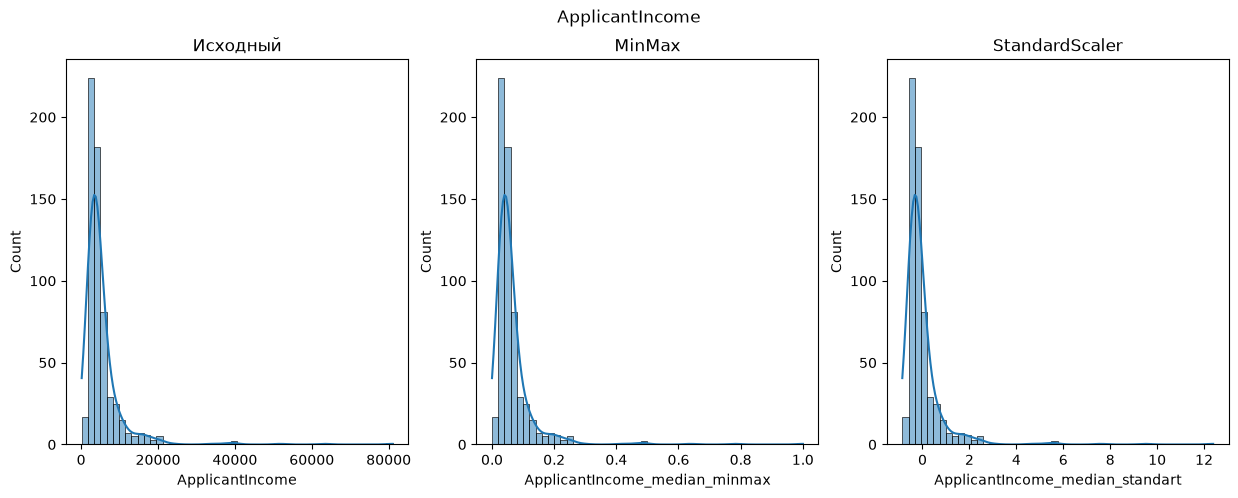

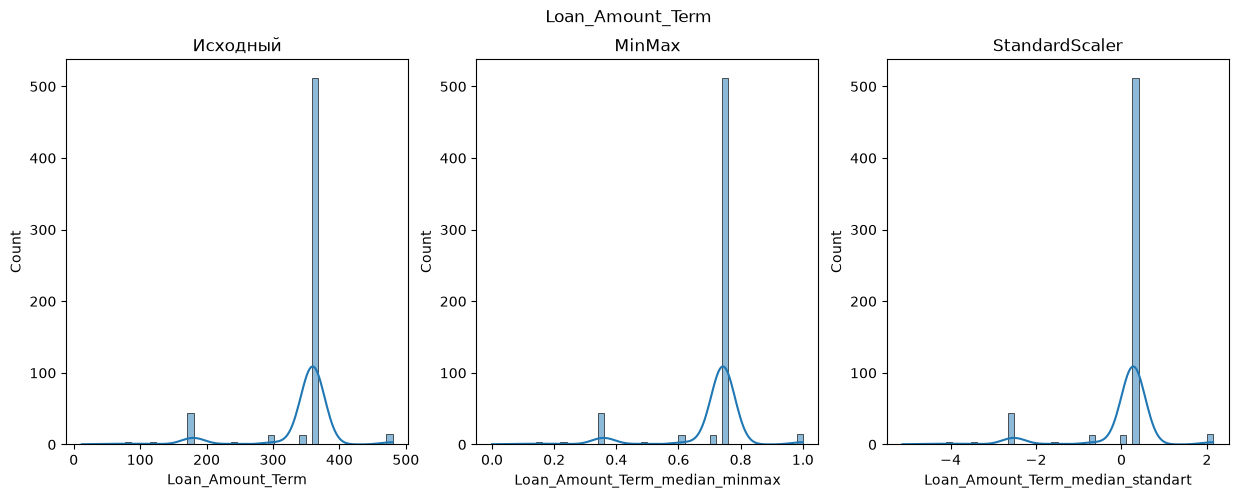

In [167]:
# Выбираем два числовых признака: скошенный ApplicantIncome и почти-константный Loan_Amount_Term
df_work['ApplicantIncome_median'] = df_work['ApplicantIncome'].fillna(df_work['ApplicantIncome'].median())
df_work['Loan_Amount_Term_median'] = df_work['Loan_Amount_Term'].fillna(df_work['Loan_Amount_Term'].median())

import sklearn.preprocessing as prp

# Минимаксная нормализация и Z-нормализация (StandardScaler)
df_work['ApplicantIncome_median_minmax'] = prp.minmax_scale(df_work['ApplicantIncome_median'])
df_work['ApplicantIncome_median_standart'] = prp.StandardScaler().fit_transform(df_work[['ApplicantIncome_median']])

df_work['Loan_Amount_Term_median_minmax'] = prp.minmax_scale(df_work['Loan_Amount_Term_median'])
df_work['Loan_Amount_Term_median_standart'] = prp.StandardScaler().fit_transform(df_work[['Loan_Amount_Term_median']])

# Визуализация гистограмм до и после масштабирования
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df_work['ApplicantIncome'], kde=True, ax=axes[0])
sns.histplot(df_work['ApplicantIncome_median_minmax'], kde=True, ax=axes[1])
sns.histplot(df_work['ApplicantIncome_median_standart'], kde=True, ax=axes[2])
axes[0].set_title('Исходный')
axes[1].set_title('MinMax')
axes[2].set_title('StandardScaler')
fig.suptitle('ApplicantIncome')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df_work['Loan_Amount_Term'], kde=True, ax=axes[0])
sns.histplot(df_work['Loan_Amount_Term_median_minmax'], kde=True, ax=axes[1])
sns.histplot(df_work['Loan_Amount_Term_median_standart'], kde=True, ax=axes[2])
axes[0].set_title('Исходный')
axes[1].set_title('MinMax')
axes[2].set_title('StandardScaler')
fig.suptitle('Loan_Amount_Term')
plt.show()


**Вывод по масштабированию**

Масштабирование не меняет сами данные, а только переводит их в другой масштаб (например, в диапазон от 0 до 1).

- MinMaxScaler просто переводит числа в промежуток от 0 до 1.
- StandardScaler делает так, чтобы среднее было 0, а разброс - 1.

Если в данных есть редкие, но очень большие значения, выбросы, лучше работает StandardScaler. MinMaxScaler из-за таких значений сильно растягивает шкалу, и обычные данные становятся мало различимы.

### Кодирование категориальных переменных

1. Выделите 2 категориальных признака: один порядковый (например, Credit_History), второй номинальный (например, Property_Area).
2. Примените к ним разные методы:
   - для порядкового: OrdinalEncoder (порядковое кодирование)
   - для номинального: OneHotEncoder + сравнение с TargetEncoder (с корректной кросс-валидацией)
3. Проверьте размерность датасета до и после кодирования. Оцените рост числа признаков.

In [168]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import numpy as np
from sklearn.metrics import roc_auc_score

n_before = df_work.shape[1]

# Порядковое кодирование Credit_History
ord_enc = OrdinalEncoder()
df_work['Credit_History_ord'] = ord_enc.fit_transform(df_work[['Credit_History']])

# OneHot для номинального Property_Area
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_arr = ohe.fit_transform(df_work[['Property_Area']])
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(['Property_Area']), index=df_work.index)
df_work = pd.concat([df_work, ohe_df], axis=1)

n_after = df_work.shape[1]
print('Признаков до кодирования:', n_before)
print('Признаков после кодирования:', n_after)
print('Рост числа признаков:', n_after - n_before)

# Сравнение OneHot vs TargetEncoding (out-of-fold, без утечки таргета)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

y = (df_work['Loan_Status'] == 'Y').astype(int)
num_feats = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
X_base = df_work[num_feats].copy()
X_base['Credit_History_ord'] = df_work['Credit_History_ord']

X_ohe = X_base.join(ohe_df)
X_te = X_base.copy()
X_te['Property_Area_te'] = 0.0

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, val_idx in skf.split(X_base, y):
    target_mean = y.iloc[tr_idx].groupby(df_work['Property_Area'].iloc[tr_idx]).mean()
    X_te.loc[val_idx, 'Property_Area_te'] = df_work['Property_Area'].iloc[val_idx].map(target_mean).fillna(y.iloc[tr_idx].mean())

def cv_auc(X):
    Xs = StandardScaler().fit_transform(X)
    lr = LogisticRegression(max_iter=1000)
    aucs = []
    for tr, va in skf.split(X, y):
        lr.fit(Xs[tr], y.iloc[tr])
        aucs.append(roc_auc_score(y.iloc[va], lr.predict_proba(Xs[va])[:, 1]))
    return np.mean(aucs)

print('ROC-AUC (OneHot):         ', round(cv_auc(X_ohe), 4))
print('ROC-AUC (TargetEncoding): ', round(cv_auc(X_te), 4))

Признаков до кодирования: 21
Признаков после кодирования: 24
Рост числа признаков: 3
ROC-AUC (OneHot):          0.7503
ROC-AUC (TargetEncoding):  0.7477


### Валидация предобработки

1. Обучите логистическую регрессию на двух версиях данных:
   - Версия 1: только удаление строк с пропусками
   - Версия 2: датасет с обработанными признаками
2. Сравните ROC-AUC на валидационной выборке. Сделайте вывод о влиянии качества предобработки на метрику.

In [169]:
# Валидация предобработки через обучение модели
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Версия 1: только удаление строк с пропусками
df_v1 = df.dropna().copy()
X1 = df_v1.drop(['Loan_Status', 'Loan_ID'], axis=1)
y1 = (df_v1['Loan_Status'] == 'Y').astype(int)
num1 = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
cat1 = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
pipe1 = Pipeline([('prep', ColumnTransformer([
    ('num', StandardScaler(), num1),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat1),
])), ('lr', LogisticRegression(max_iter=1000))])
auc1 = cross_val_score(pipe1, X1, y1, cv=5, scoring='roc_auc').mean()

# Версия 2: датасет с обработанными признаками (df_work)
X2 = df_work[['ApplicantIncome_median', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term_median', 'Credit_History_ord', 'Property_Area_Semiurban', 'Property_Area_Urban','SimpleImputer_ind']]
y2 = (df_work['Loan_Status'] == 'Y').astype(int)
pipe2 = Pipeline([('scale', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
auc2 = cross_val_score(pipe2, X2, y2, cv=5, scoring='roc_auc').mean()

print('ROC-AUC (удаление строк с пропусками):', round(auc1, 4))
print('ROC-AUC (обработанные признаки):       ', round(auc2, 4))

comparison = pd.DataFrame({'Версия': ['Удаление строк', 'Обработанные признаки'], 'Строк': [len(df_v1), len(df_work)], 'ROC-AUC': [auc1, auc2]})
display(comparison)

ROC-AUC (удаление строк с пропусками): 0.7726
ROC-AUC (обработанные признаки):        0.7519


,Версия,Строк,ROC-AUC
0,Удаление строк,480,0.772621
1,Обработанные признаки,614,0.751897


## 📝 Выводы

1. Пропуски проще всего заполнять медианой (серединное значение) и помечать, что значение было пустым. Это просто и хорошо работает. Модельное восстановление (когда пропуск угадывается по другим признакам) точнее, но сложнее, а пропусков у нас мало, поэтому большой разницы не видно.

2. Масштабирование не меняет форму данных, а только их масштаб. MinMaxScaler переводит всё в диапазон от 0 до 1, StandardScaler делает среднее 0 и разброс 1. При наличии выбросов лучше работает StandardScaler.

3. Самая опасная ошибка - утечка таргета при TargetEncoding. Если считать среднее ответа по всей выборке и сразу использовать его, модель подглядывает правильный ответ. Этого мы избежали: считали среднее только на обучающей части и применяли к тестовой.